# Reservoir Data Exploration

Based on:
- **Steyaert et al. (2022)** — ResOpsUS dataset
- **Turner et al. (2021)** — STARFIT parameters
- **Steyaert et al. (2025)** — Data-derived reservoir operations in PCR-GLOBWB 2

This notebook covers three things:
1. Overview of the ResOpsUS+CARS dataset (data availability, record lengths, dam characteristics)
2. Summary of STARFIT parameters from Turner's CSV
3. Point model demo on **Lake Koocanusa (GRAND_ID 297)** — generic vs STARFIT release scheme

## 0. Imports and file paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import io
import math
import warnings
warnings.filterwarnings('ignore')

# ----------------------------------------------------------------
# FILE PATHS — adjust if your working directory is different
# ----------------------------------------------------------------
PATH_RESOPS  = 'data/ResOpsUS+CARS_v10/v1.0/attributes/resops.csv'
PATH_GRAND   = 'data/ResOpsUS+CARS_v10/v1.0/attributes/grand.csv'
PATH_TURNER  = 'RF/Turner_ResOpsUS_params.csv'
PATH_DAM297  = 'data/ResOpsUS+CARS_v10/v1.0/time_series/csv/297.csv'

DAM_ID   = 297
DAM_NAME = 'Lake Koocanusa'
CAP_MCM  = 7434.2        # storage capacity from GRanD [MCM]
SECONDS_PER_DAY = 86400

print('Imports done.')

Imports done.


## 1. Load data

In [2]:
# ResOpsUS attributes
resops = pd.read_csv(PATH_RESOPS)
grand  = pd.read_csv(PATH_GRAND)

# Fix mixed date formats in resops
for col in ['STORAGE_START', 'STORAGE_END', 'INFLOW_START', 'INFLOW_END']:
    resops[col] = pd.to_datetime(resops[col], format='mixed', errors='coerce')

# Turner STARFIT parameters — strip quotes from header
with open(PATH_TURNER, 'r') as f:
    content = f.read().replace('"', '')
turner = pd.read_csv(io.StringIO(content))
turner['grand_id'] = pd.to_numeric(turner['grand_id'], errors='coerce')
turner = turner.dropna(subset=['grand_id'])
turner['grand_id'] = turner['grand_id'].astype(int)
turner = turner.replace([np.inf, -np.inf], np.nan)  # inf → NaN for analysis

# Dam 297 time series
df297 = pd.read_csv(PATH_DAM297)
df297['date'] = pd.to_datetime(df297['date'])

# Merge resops + grand for combined attributes
merged = resops.merge(
    grand[['GRAND_ID', 'RES_NAME', 'CAP_MCM', 'USE_IRRI',
           'USE_ELEC', 'USE_SUPP', 'USE_FCON', 'DIS_AVG_LS']],
    on='GRAND_ID', how='inner'
)
merged['record_years'] = (
    (merged['STORAGE_END'] - merged['STORAGE_START']).dt.days / 365
).clip(lower=0)

print(f'ResOpsUS: {len(resops)} dams')
print(f'Turner params: {len(turner)} dams')
print(f'Dam 297 time series: {len(df297)} days '
      f'({df297["date"].min().date()} to {df297["date"].max().date()})')

ResOpsUS: 676 dams
Turner params: 668 dams
Dam 297 time series: 16801 days (1975-01-01 to 2020-12-30)


## 2. ResOpsUS overview — data availability and record lengths

In [3]:
has_storage = (resops['STORAGE']  == True).sum()
has_inflow  = (resops['INFLOW']   == True).sum()
has_outflow = (resops['OUTFLOW']  == True).sum()
has_all     = ((resops['STORAGE'] == True) &
               (resops['INFLOW']  == True) &
               (resops['OUTFLOW'] == True)).sum()

print('=== Data availability ===')
print(f'Total dams:                 {len(resops)}')
print(f'With storage:               {has_storage}')
print(f'With inflow:                {has_inflow}')
print(f'With outflow:               {has_outflow}')
print(f'With all three (S+I+O):     {has_all}')
print(f'Median record length:       {merged["record_years"].median():.1f} years')
print(f'Storage capacity range:     '
      f'{merged["CAP_MCM"].min():.0f} – {merged["CAP_MCM"].max():.0f} MCM')

=== Data availability ===
Total dams:                 676
With storage:               625
With inflow:                313
With outflow:               517
With all three (S+I+O):     283
Median record length:       41.0 years
Storage capacity range:     5 – 36700 MCM


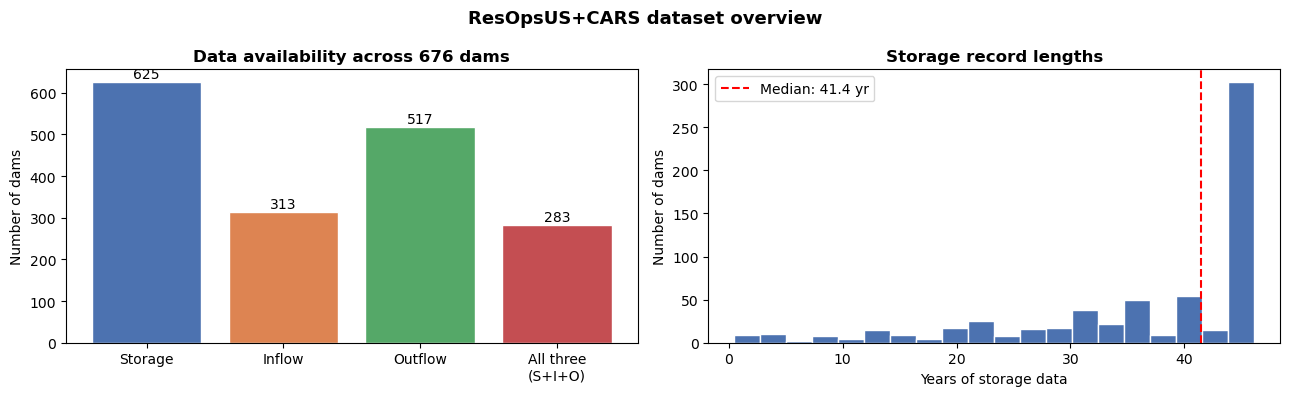

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Data availability bar chart
categories = ['Storage', 'Inflow', 'Outflow', 'All three\n(S+I+O)']
counts     = [has_storage, has_inflow, has_outflow, has_all]
colors     = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = axes[0].bar(categories, counts, color=colors, edgecolor='white')
axes[0].set_title('Data availability across 676 dams', fontweight='bold')
axes[0].set_ylabel('Number of dams')
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 3, str(count),
                 ha='center', va='bottom', fontsize=10)

# Record length histogram
valid_years = merged['record_years'][merged['record_years'] > 0]
axes[1].hist(valid_years, bins=20, color='#4C72B0', edgecolor='white')
axes[1].axvline(valid_years.median(), color='red', linestyle='--',
                label=f'Median: {valid_years.median():.1f} yr')
axes[1].set_title('Storage record lengths', fontweight='bold')
axes[1].set_xlabel('Years of storage data')
axes[1].set_ylabel('Number of dams')
axes[1].legend()

plt.suptitle('ResOpsUS+CARS dataset overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. EDA — Turner STARFIT parameters (Turner et al. 2021)

The Turner CSV (`RF/Turner_ResOpsUS_params.csv`) contains 10 fitted STARFIT parameters per dam.

Each dam has two harmonic curves — a **flood bound** and a **conservation bound** — defined by:
- **p1** = mu (baseline level, % of capacity)
- **p2** = alpha (sine amplitude)
- **p3** = beta (cosine amplitude)
- **max / min** = hard caps that constrain the curve

The equation is: `S(t) = mu + alpha * sin(2π t/52) + beta * cos(2π t/52)`

`inf` or `-inf` means no constraint was fitted in that direction for that dam.

In [5]:
param_cols = ['flood_p1','flood_p2','flood_p3','max_flood','min_flood',
              'conserve_p1','conserve_p2','conserve_p3','conserve_max','conserve_min']

n_total      = len(turner)
n_any_nan    = turner.isna().any(axis=1).sum()
n_all_finite = turner.dropna().shape[0]

print('=== Completeness ===')
print(f'Total dams:                    {n_total}')
print(f'Dams with any inf/-inf:        {n_any_nan}  ({n_any_nan/n_total*100:.0f}%)')
print(f'Dams fully finite (usable):    {n_all_finite}  ({n_all_finite/n_total*100:.0f}%)')
print()

# Per-parameter: how many dams have a finite value
print('=== Finite values per parameter ===')
for col in param_cols:
    n_finite = turner[col].notna().sum()
    print(f'  {col:15s}: {n_finite:4d} / {n_total}  ({n_finite/n_total*100:.0f}%)')

print()
print('=== Descriptive statistics (finite values only) ===')
summary = turner[param_cols].describe().T[['mean','std','min','25%','50%','75%','max']].round(2)
print(summary.to_string())

=== Completeness ===
Total dams:                    668
Dams with any inf/-inf:        648  (97%)
Dams fully finite (usable):    20  (3%)

=== Finite values per parameter ===
  flood_p1       :  616 / 668  (92%)
  flood_p2       :  616 / 668  (92%)
  flood_p3       :  616 / 668  (92%)
  max_flood      :  206 / 668  (31%)
  min_flood      :  223 / 668  (33%)
  conserve_p1    :  616 / 668  (92%)
  conserve_p2    :  616 / 668  (92%)
  conserve_p3    :  616 / 668  (92%)
  conserve_max   :  127 / 668  (19%)
  conserve_min   :  296 / 668  (44%)

=== Descriptive statistics (finite values only) ===
               mean    std    min    25%    50%    75%     max
flood_p1      59.21  29.25   0.00  36.91  62.61  85.83  109.47
flood_p2       3.50   9.92 -72.21  -0.03   0.97   5.40   79.68
flood_p3      -8.06  12.01 -72.35 -10.72  -3.63  -0.19   14.00
max_flood     80.36  26.61   0.07  62.82  96.18  99.76  100.00
min_flood     46.43  24.84   0.63  26.68  46.38  66.45   99.72
conserve_p1   32.10  25.

In [6]:
# ---------------------------------------------------------------
# Find the 20 fully finite dams and show their names
# ---------------------------------------------------------------

param_cols = ['flood_p1','flood_p2','flood_p3','max_flood','min_flood',
              'conserve_p1','conserve_p2','conserve_p3','conserve_max','conserve_min']

# Get dams where ALL 10 parameters are finite
fully_finite = turner.dropna(subset=param_cols)

# Merge with grand to get reservoir names and attributes
fully_finite_named = fully_finite.merge(
    grand[['GRAND_ID', 'RES_NAME', 'CAP_MCM', 'USE_IRRI', 
           'USE_ELEC', 'USE_SUPP', 'USE_FCON', 'MAIN_BASIN']],
    left_on='grand_id', right_on='GRAND_ID',
    how='left'
)

# Also add record length from resops
fully_finite_named = fully_finite_named.merge(
    resops[['GRAND_ID', 'STORAGE_START', 'STORAGE_END', 
            'INFLOW', 'OUTFLOW', 'STORAGE']],
    on='GRAND_ID', how='left'
)
fully_finite_named['record_years'] = (
    (fully_finite_named['STORAGE_END'] - fully_finite_named['STORAGE_START']).dt.days / 365
).clip(lower=0)

# Print the results
print(f'=== {len(fully_finite_named)} fully finite dams ===\n')
display_cols = ['GRAND_ID', 'RES_NAME', 'CAP_MCM', 'record_years',
                'MAIN_BASIN', 'USE_IRRI', 'USE_ELEC', 'USE_SUPP', 'USE_FCON']
print(fully_finite_named[display_cols].to_string(index=False))

=== 20 fully finite dams ===

 GRAND_ID           RES_NAME  CAP_MCM  record_years  MAIN_BASIN  USE_IRRI  USE_ELEC  USE_SUPP  USE_FCON
      160      Prosser Creek     35.3     19.008219         NaN       1.0       0.0       0.0       3.0
     1709  Summersville Lake    509.9     34.926027         NaN       0.0       0.0       0.0       3.0
     1714      Cave Run Lake    757.5      0.000000         NaN       0.0       0.0       0.0       3.0
     1735      Fishtrap Lake    202.7     30.427397         NaN       0.0       0.0       0.0       3.0
     1739      Buckhorn Lake    207.1      0.000000         NaN       0.0       0.0       0.0       3.0
     1744    Carr Creek Lake     58.8     44.084932         NaN       0.0       0.0       0.0       3.0
      297     Lake Koocanusa   7434.2     45.775342         NaN       0.0       3.0       0.0       1.0
      305  Pend Oreille Lake   1424.7     45.430137         NaN       0.0       3.0       0.0       1.0
      316      Flathead Lake   220

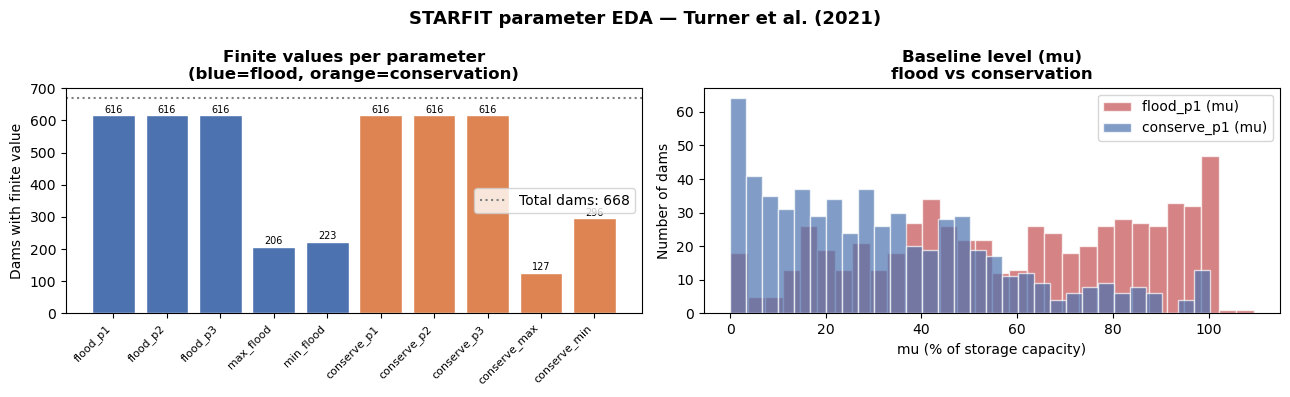

In [7]:
# Plot 1: finite value counts per parameter
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

n_finite_vals = [turner[c].notna().sum() for c in param_cols]
colors_p = ['#4C72B0']*5 + ['#DD8452']*5
bars = axes[0].bar(param_cols, n_finite_vals, color=colors_p, edgecolor='white')
axes[0].axhline(n_total, color='grey', linestyle=':', linewidth=1.5,
                label=f'Total dams: {n_total}')
axes[0].set_title('Finite values per parameter\n(blue=flood, orange=conservation)',
                  fontweight='bold')
axes[0].set_ylabel('Dams with finite value')
axes[0].set_xticklabels(param_cols, rotation=45, ha='right', fontsize=8)
axes[0].legend()
for bar, val in zip(bars, n_finite_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', va='bottom', fontsize=7)

# Plot 2: mu (p1) distributions flood vs conservation
axes[1].hist(turner['flood_p1'].dropna(), bins=30, color='#C44E52',
             alpha=0.7, edgecolor='white', label='flood_p1 (mu)')
axes[1].hist(turner['conserve_p1'].dropna(), bins=30, color='#4C72B0',
             alpha=0.7, edgecolor='white', label='conserve_p1 (mu)')
axes[1].set_title('Baseline level (mu)\nflood vs conservation', fontweight='bold')
axes[1].set_xlabel('mu (% of storage capacity)')
axes[1].set_ylabel('Number of dams')
axes[1].legend()

plt.suptitle('STARFIT parameter EDA — Turner et al. (2021)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

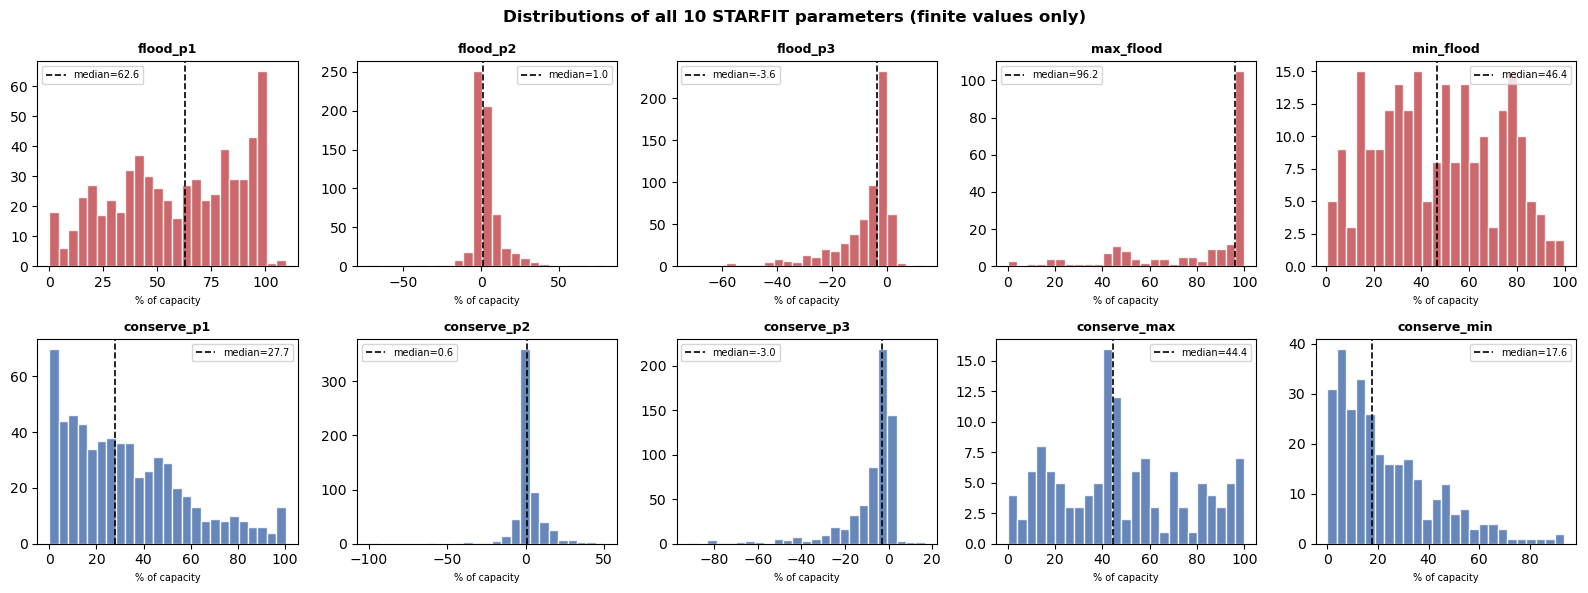

In [8]:
# Plot 3: distributions of all 10 parameters (finite values only)
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()

flood_color    = '#C44E52'
conserve_color = '#4C72B0'

for i, col in enumerate(param_cols):
    color = flood_color if i < 5 else conserve_color
    data  = turner[col].dropna()
    axes[i].hist(data, bins=25, color=color, edgecolor='white', alpha=0.85)
    axes[i].axvline(data.median(), color='black', linestyle='--', linewidth=1.2,
                    label=f'median={data.median():.1f}')
    axes[i].set_title(col, fontweight='bold', fontsize=9)
    axes[i].set_xlabel('% of capacity', fontsize=7)
    axes[i].legend(fontsize=7)

plt.suptitle('Distributions of all 10 STARFIT parameters (finite values only)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

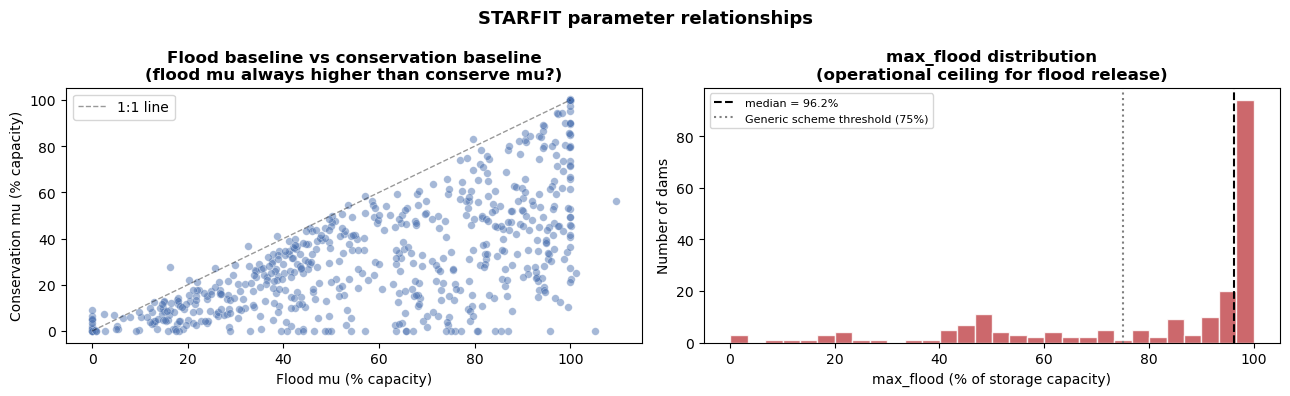

Dams where max_flood > 75% (i.e. higher ceiling than generic scheme): 69%
This means the generic 75% threshold is too conservative for most dams.


In [9]:
# Plot 4: scatter — flood mu vs conservation mu, colored by which params are inf
# This shows the relationship between the two baseline levels
both_finite = turner[turner['flood_p1'].notna() & turner['conserve_p1'].notna()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(both_finite['flood_p1'], both_finite['conserve_p1'],
                alpha=0.5, color='#4C72B0', edgecolors='white', linewidths=0.3, s=30)
axes[0].plot([0, 100], [0, 100], 'k--', linewidth=1, alpha=0.4, label='1:1 line')
axes[0].set_xlabel('Flood mu (% capacity)')
axes[0].set_ylabel('Conservation mu (% capacity)')
axes[0].set_title('Flood baseline vs conservation baseline\n(flood mu always higher than conserve mu?)',
                  fontweight='bold')
axes[0].legend()

# Plot 5: max_flood distribution — the operational ceiling that triggers flood release
axes[1].hist(turner['max_flood'].dropna(), bins=30, color='#C44E52',
             edgecolor='white', alpha=0.85)
axes[1].axvline(turner['max_flood'].median(), color='black', linestyle='--',
                label=f'median = {turner["max_flood"].median():.1f}%')
axes[1].axvline(75, color='grey', linestyle=':', linewidth=1.5,
                label='Generic scheme threshold (75%)')
axes[1].set_title('max_flood distribution\n(operational ceiling for flood release)',
                  fontweight='bold')
axes[1].set_xlabel('max_flood (% of storage capacity)')
axes[1].set_ylabel('Number of dams')
axes[1].legend(fontsize=8)

plt.suptitle('STARFIT parameter relationships', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Key observation
pct_above_75 = (turner['max_flood'].dropna() > 75).mean() * 100
print(f'Dams where max_flood > 75% (i.e. higher ceiling than generic scheme): '
      f'{pct_above_75:.0f}%')
print(f'This means the generic 75% threshold is too conservative for most dams.')

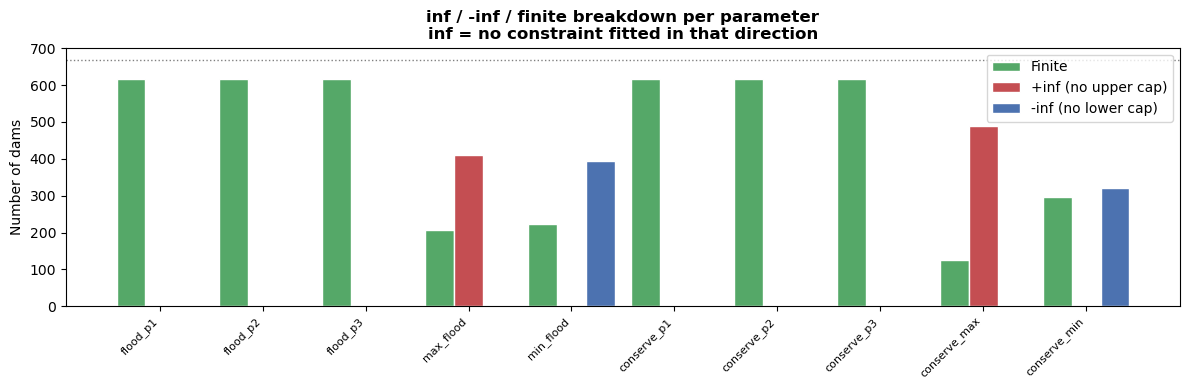

In [10]:
# Plot 6: inf/-inf breakdown per parameter
# For each parameter, count: finite / +inf / -inf

# Reload raw turner to check inf values before replacement
with open(PATH_TURNER, 'r') as f:
    content_raw2 = f.read().replace('"', '')
turner_raw2 = pd.read_csv(io.StringIO(content_raw2))
turner_raw2['grand_id'] = pd.to_numeric(turner_raw2['grand_id'], errors='coerce')
turner_raw2 = turner_raw2.dropna(subset=['grand_id'])

inf_counts  = {}
ninf_counts = {}
fin_counts  = {}

for col in param_cols:
    col_vals = turner_raw2[col]
    inf_counts[col]  = np.isinf(col_vals) & (col_vals > 0)
    ninf_counts[col] = np.isinf(col_vals) & (col_vals < 0)
    fin_counts[col]  = ~np.isinf(col_vals) & col_vals.notna()

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(param_cols))
width = 0.28

ax.bar(x - width, [fin_counts[c].sum()  for c in param_cols],
       width, label='Finite', color='#55A868', edgecolor='white')
ax.bar(x,         [inf_counts[c].sum()  for c in param_cols],
       width, label='+inf (no upper cap)', color='#C44E52', edgecolor='white')
ax.bar(x + width, [ninf_counts[c].sum() for c in param_cols],
       width, label='-inf (no lower cap)', color='#4C72B0', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(param_cols, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Number of dams')
ax.set_title('inf / -inf / finite breakdown per parameter\n'
             'inf = no constraint fitted in that direction', fontweight='bold')
ax.legend()
ax.axhline(n_total, color='grey', linestyle=':', linewidth=1, label=f'Total: {n_total}')

plt.tight_layout()
plt.show()

## 4. Dam 297 — Lake Koocanusa, Montana

**Why this dam?**
- Longest clean record: ~45 years (1975–2020)
- All STARFIT parameters are finite
- Large hydropower reservoir (7434 MCM capacity)
- Complete storage, inflow and outflow data

In [11]:
print(f'=== Dam {DAM_ID}: {DAM_NAME} ===')
print(f'Storage capacity (GRanD):     {CAP_MCM:.0f} MCM')
print(f'Observed storage range:       '
      f'{df297["storage"].min():.0f} – {df297["storage"].max():.0f} MCM')
print(f'Max storage as % of capacity: '
      f'{df297["storage"].max()/CAP_MCM*100:.1f}%')
print(f'Storage missing:              '
      f'{df297["storage"].isna().sum()} days '
      f'({df297["storage"].isna().mean()*100:.1f}%)')
print(f'Inflow range:                 '
      f'{df297["inflow"].min():.0f} – {df297["inflow"].max():.0f} m³/s')
print(f'Average inflow:               {df297["inflow"].mean():.0f} m³/s')
print()

# STARFIT parameters for dam 297
with open(PATH_TURNER, 'r') as f:
    content_raw = f.read().replace('"', '')
turner_raw = pd.read_csv(io.StringIO(content_raw))
turner_raw['grand_id'] = pd.to_numeric(turner_raw['grand_id'], errors='coerce')
dam_params = turner_raw[turner_raw['grand_id'] == DAM_ID].iloc[0]

print('STARFIT parameters (raw values, % of capacity):')
for col in ['flood_p1','flood_p2','flood_p3','max_flood','min_flood',
            'conserve_p1','conserve_p2','conserve_p3','conserve_max','conserve_min']:
    print(f'  {col:15s}: {dam_params[col]}')

=== Dam 297: Lake Koocanusa ===
Storage capacity (GRanD):     7434 MCM
Observed storage range:       365 – 7171 MCM
Max storage as % of capacity: 96.5%
Storage missing:              796 days (4.7%)
Inflow range:                 14 – 2446 m³/s
Average inflow:               310 m³/s

STARFIT parameters (raw values, % of capacity):
  flood_p1       : 69.609
  flood_p2       : -21.37
  flood_p3       : -10.804
  max_flood      : 79.379
  min_flood      : 53.715
  conserve_p1    : 50.646
  conserve_p2    : -38.376
  conserve_p3    : -2.724
  conserve_max   : 63.778
  conserve_min   : 13.631


In [12]:
# Generate STARFIT seasonal curves for dam 297
def starfit_bound(week, mu, alpha, beta, lower=None, upper=None):
    """Eq. 5 from Steyaert et al. (2025) / Turner et al. (2021).
    Returns bound as % of storage capacity."""
    val = (mu
           + alpha * np.sin(2 * math.pi * week / 52)
           + beta  * np.cos(2 * math.pi * week / 52))
    if lower is not None and not (isinstance(lower, float) and math.isinf(lower)):
        val = max(val, lower)
    if upper is not None and not (isinstance(upper, float) and math.isinf(upper)):
        val = min(val, upper)
    return float(val)

weeks = list(range(1, 53))

flood_pct = [starfit_bound(
    w,
    dam_params['flood_p1'], dam_params['flood_p2'], dam_params['flood_p3'],
    dam_params['min_flood'], dam_params['max_flood']
) for w in weeks]

conserve_pct = [starfit_bound(
    w,
    dam_params['conserve_p1'], dam_params['conserve_p2'], dam_params['conserve_p3'],
    dam_params['conserve_min'], dam_params['conserve_max']
) for w in weeks]

# Convert % → MCM
flood_mcm    = [v * CAP_MCM / 100 for v in flood_pct]
conserve_mcm = [v * CAP_MCM / 100 for v in conserve_pct]

print(f'Flood curve:        {min(flood_mcm):.0f} – {max(flood_mcm):.0f} MCM')
print(f'Conservation curve: {min(conserve_mcm):.0f} – {max(conserve_mcm):.0f} MCM')

Flood curve:        3993 – 5901 MCM
Conservation curve: 1013 – 4741 MCM


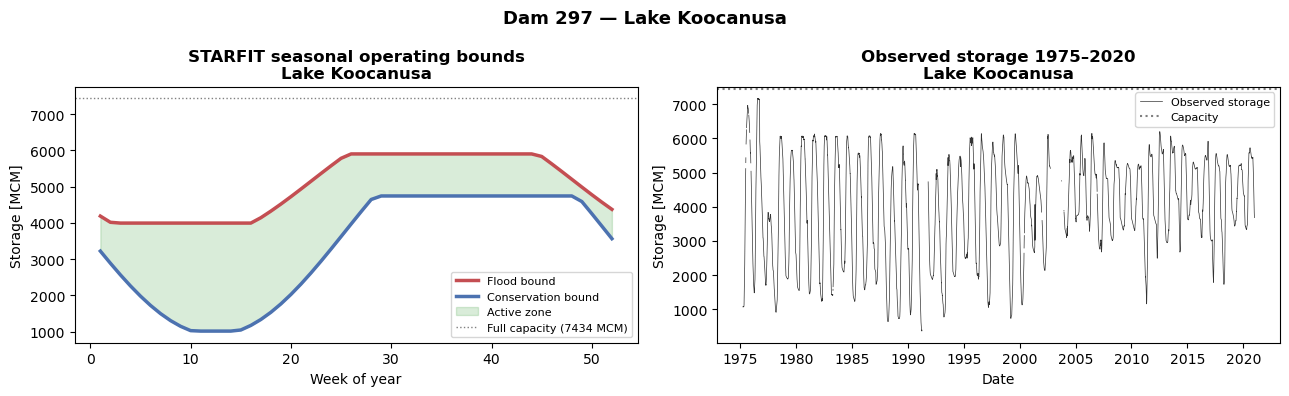

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# STARFIT seasonal curves
axes[0].plot(weeks, flood_mcm,    color='#C44E52', linewidth=2.5, label='Flood bound')
axes[0].plot(weeks, conserve_mcm, color='#4C72B0', linewidth=2.5, label='Conservation bound')
axes[0].fill_between(weeks, conserve_mcm, flood_mcm,
                     alpha=0.15, color='green', label='Active zone')
axes[0].axhline(CAP_MCM, color='grey', linestyle=':', linewidth=1,
                label=f'Full capacity ({CAP_MCM:.0f} MCM)')
axes[0].set_title(f'STARFIT seasonal operating bounds\n{DAM_NAME}', fontweight='bold')
axes[0].set_xlabel('Week of year')
axes[0].set_ylabel('Storage [MCM]')
axes[0].legend(fontsize=8)

# Observed storage time series
axes[1].plot(df297['date'], df297['storage'],
             color='black', linewidth=0.5, alpha=0.8, label='Observed storage')
axes[1].axhline(CAP_MCM, color='grey', linestyle=':', label='Capacity')
axes[1].set_title(f'Observed storage 1975–2020\n{DAM_NAME}', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Storage [MCM]')
axes[1].legend(fontsize=8)

plt.suptitle(f'Dam {DAM_ID} — {DAM_NAME}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Point model — generic vs STARFIT on dam 297

This is a simplified single-reservoir simulation based on Steyaert et al. (2025).

**Generic scheme** (current PCR-GLOBWB default):
- Active zone: fixed 10%–75% of capacity
- No seasonality, no demand

**STARFIT scheme**:
- Active zone: seasonal flood and conservation bounds from Turner parameters
- Hydropower-like release logic (dam 297 is a hydropower reservoir)

Both are driven by the **observed inflow** from ResOpsUS+CARS.

In [14]:
# Simulation setup
sim_df = df297[df297['date'] >= '1980-01-01'].copy().reset_index(drop=True)

# Convert inflow from m³/s → MCM/day
sim_df['inflow_mcm'] = sim_df['inflow'] * SECONDS_PER_DAY / 1e6
avg_inflow_mcm = sim_df['inflow_mcm'].mean()

# Build week-of-year lookup for STARFIT bounds [MCM]
week_lookup_flood    = {w: flood_mcm[w-1]    for w in range(1, 53)}
week_lookup_conserve = {w: conserve_mcm[w-1] for w in range(1, 53)}

print(f'Simulation period: {sim_df["date"].min().date()} to {sim_df["date"].max().date()}')
print(f'Average inflow: {avg_inflow_mcm:.2f} MCM/day ({avg_inflow_mcm/SECONDS_PER_DAY*1e6:.0f} m³/s)')

Simulation period: 1980-01-01 to 2020-12-30
Average inflow: 26.98 MCM/day (312 m³/s)


In [15]:
def reduction_factor(sc, smin, smax):
    """Eq. 3 — fraction of active zone currently filled."""
    if smax <= smin:
        return 0.0
    return float(np.clip((sc - smin) / (smax - smin), 0.0, 1.0))


def generic_release_fn(sc, avg_q, cap):
    """Eq. 4 — generic PCR-GLOBWB release scheme."""
    smin = 0.10 * cap
    smax = 0.75 * cap
    if sc <= smin:
        return 0.0
    elif sc <= smax:
        return reduction_factor(sc, smin, smax) * avg_q
    else:
        frac = np.clip((sc - smax) / (cap - smax), 0.0, 1.0)
        return avg_q + frac * (2.3 * avg_q - avg_q)


def starfit_release_fn(sc, avg_q, cap, flood_b, conserve_b):
    """Simplified STARFIT hydropower-like release.
    Active zone: between conservation bound and flood bound.
    Flood release triggers at flood_bound, NOT at physical capacity."""
    smin = conserve_b
    smax = flood_b
    if smax <= smin:
        smin = 0.10 * cap   # fallback
    if sc <= smin:
        return 0.0
    elif sc <= smax:
        return reduction_factor(sc, smin, smax) * avg_q
    else:
        # Above flood bound — release to bring storage back
        return avg_q + (sc - smax)


def run_simulation(sim_df, cap, avg_q, mode='generic'):
    """Run point model forward in time. Returns storage and release arrays."""
    # Start from first available observed storage
    storage = sim_df['storage'].dropna().iloc[0]
    storages = []
    releases = []

    for _, row in sim_df.iterrows():
        inflow = row['inflow_mcm'] if not np.isnan(row['inflow_mcm']) else avg_q
        woy    = int(row['weekofyear'])

        if mode == 'generic':
            release = generic_release_fn(storage, avg_q, cap)
        else:
            flood_b    = week_lookup_flood.get(woy,    flood_mcm[25])
            conserve_b = week_lookup_conserve.get(woy, conserve_mcm[25])
            release    = starfit_release_fn(storage, avg_q, cap, flood_b, conserve_b)

        # Physical constraints: release ≤ available water, storage ≤ capacity
        available = storage + inflow
        release   = min(max(release, 0.0), available)
        storage   = min(available - release, cap)

        storages.append(storage)
        releases.append(release)

    return np.array(storages), np.array(releases)


storage_generic, release_generic = run_simulation(sim_df, CAP_MCM, avg_inflow_mcm, mode='generic')
storage_starfit, release_starfit = run_simulation(sim_df, CAP_MCM, avg_inflow_mcm, mode='starfit')

# Compute RMSE where observed storage is available
obs = sim_df['storage'].values
mask = ~np.isnan(obs)
rmse_generic = np.sqrt(np.mean((storage_generic[mask] - obs[mask])**2))
rmse_starfit = np.sqrt(np.mean((storage_starfit[mask] - obs[mask])**2))

print(f'RMSE — generic scheme:  {rmse_generic:.0f} MCM')
print(f'RMSE — STARFIT scheme:  {rmse_starfit:.0f} MCM')
print(f'Improvement:            {(rmse_generic - rmse_starfit)/rmse_generic*100:.0f}%')

RMSE — generic scheme:  1325 MCM
RMSE — STARFIT scheme:  968 MCM
Improvement:            27%


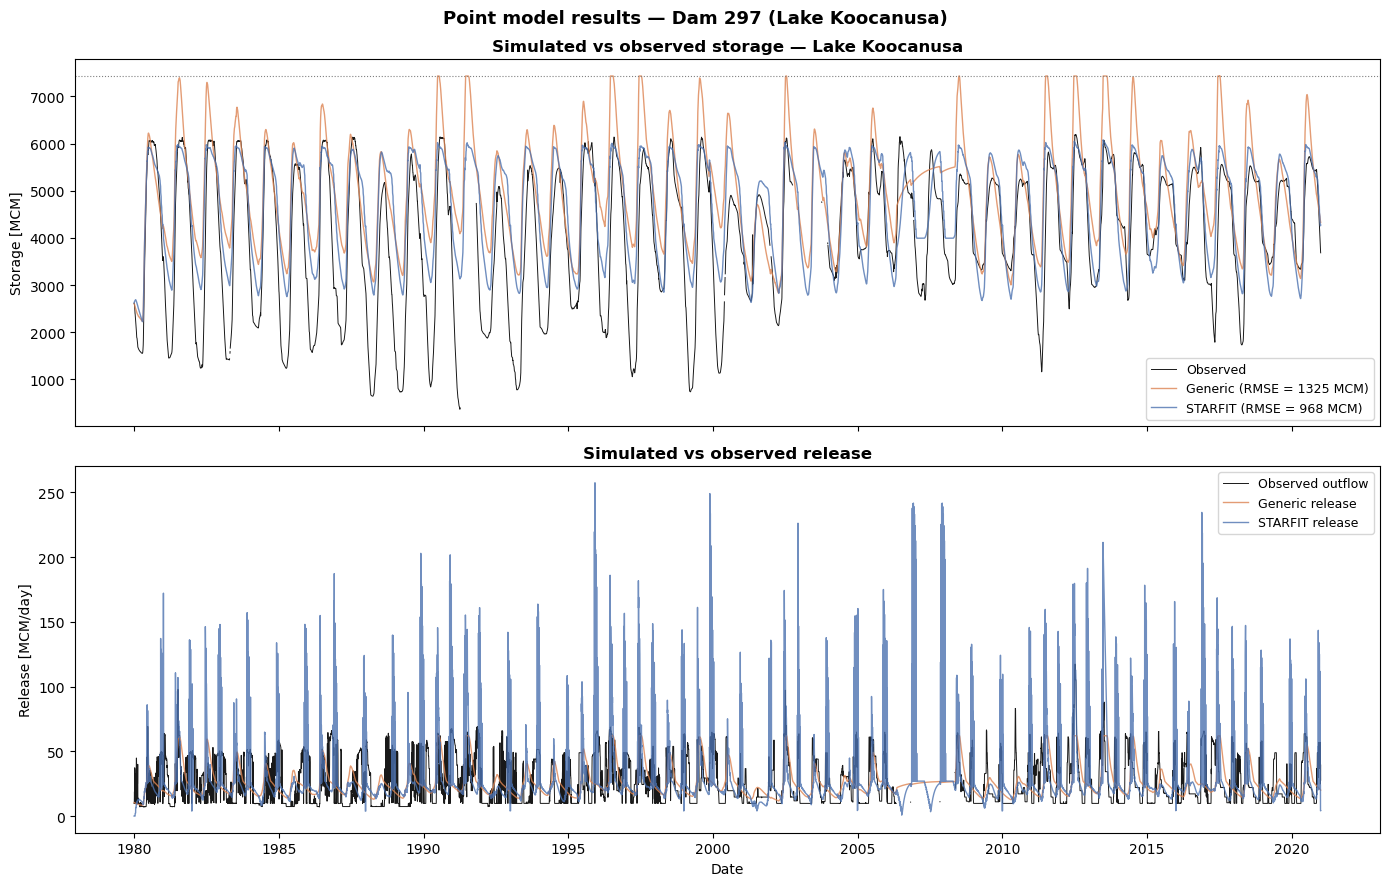

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

dates = sim_df['date'].values

# Storage comparison
axes[0].plot(dates, obs,             color='black',   linewidth=0.7, alpha=0.9,
             label='Observed')
axes[0].plot(dates, storage_generic, color='#DD8452', linewidth=1.0, alpha=0.8,
             label=f'Generic (RMSE = {rmse_generic:.0f} MCM)')
axes[0].plot(dates, storage_starfit, color='#4C72B0', linewidth=1.0, alpha=0.8,
             label=f'STARFIT (RMSE = {rmse_starfit:.0f} MCM)')
axes[0].set_ylabel('Storage [MCM]')
axes[0].set_title(f'Simulated vs observed storage — {DAM_NAME}', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].axhline(CAP_MCM, color='grey', linestyle=':', linewidth=0.8,
                label='Capacity')

# Release comparison
axes[1].plot(dates, sim_df['outflow'] * SECONDS_PER_DAY / 1e6,
             color='black',   linewidth=0.7, alpha=0.9, label='Observed outflow')
axes[1].plot(dates, release_generic, color='#DD8452', linewidth=1.0, alpha=0.8,
             label='Generic release')
axes[1].plot(dates, release_starfit, color='#4C72B0', linewidth=1.0, alpha=0.8,
             label='STARFIT release')
axes[1].set_ylabel('Release [MCM/day]')
axes[1].set_xlabel('Date')
axes[1].set_title('Simulated vs observed release', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle(f'Point model results — Dam {DAM_ID} ({DAM_NAME})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()